In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

Подключите один из csv файлов в папке

In [ ]:
df = pd.read_csv('train.csv')

Просмотрите датасет

In [ ]:
df.head()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Ecology_2,Ecology_3,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Shops_2,Price
0,11809,27,3.0,115.027311,NaN,10.0,4,10.0,2014,0.075424,B,B,11,3097,0,NaN,0,0,B,305018.871089
1,3013,22,1.0,39.832524,23.169223,8.0,7,8.0,1966,0.118537,B,B,30,6207,1,1183.0,1,0,B,177734.553407
2,8215,1,3.0,78.342215,47.671972,10.0,2,17.0,1988,0.025609,B,B,33,5261,0,240.0,3,1,B,282078.720850
3,2352,1,1.0,40.409907,NaN,1.0,10,22.0,1977,0.007122,B,B,1,264,0,NaN,0,1,B,168106.007630
4,13866,94,2.0,64.285067,38.562517,9.0,16,16.0,1972,0.282798,B,B,33,8667,2,NaN,0,6,B,343995.102962


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             10000 non-null  int64  
 1   DistrictId     10000 non-null  int64  
 2   Rooms          10000 non-null  float64
 3   Square         10000 non-null  float64
 4   LifeSquare     7887 non-null   float64
 5   KitchenSquare  10000 non-null  float64
 6   Floor          10000 non-null  int64  
 7   HouseFloor     10000 non-null  float64
 8   HouseYear      10000 non-null  int64  
 9   Ecology_1      10000 non-null  float64
 10  Ecology_2      10000 non-null  object 
 11  Ecology_3      10000 non-null  object 
 12  Social_1       10000 non-null  int64  
 13  Social_2       10000 non-null  int64  
 14  Social_3       10000 non-null  int64  
 15  Healthcare_1   5202 non-null   float64
 16  Helthcare_2    10000 non-null  int64  
 17  Shops_1        10000 non-null  int64  
 18  Shops_2

Посмотрите есть ли пропуски в переменных

In [ ]:
print('\nКоличество пропусков по столбцам:')
print(df.isna().sum())


Количество пропусков по столбцам:
Id                  0
DistrictId          0
Rooms               0
Square              0
LifeSquare       2113
KitchenSquare       0
Floor               0
HouseFloor          0
HouseYear           0
Ecology_1           0
Ecology_2           0
Ecology_3           0
Social_1            0
Social_2            0
Social_3            0
Healthcare_1     4798
Helthcare_2         0
Shops_1             0
Shops_2             0
Price               0
dtype: int64


Посмотрите уникальные значения целевого признака

In [ ]:
df['Price'].nunique()

10000

Постройте график распределения целевого признака


Text(0.5, 0, 'Price')

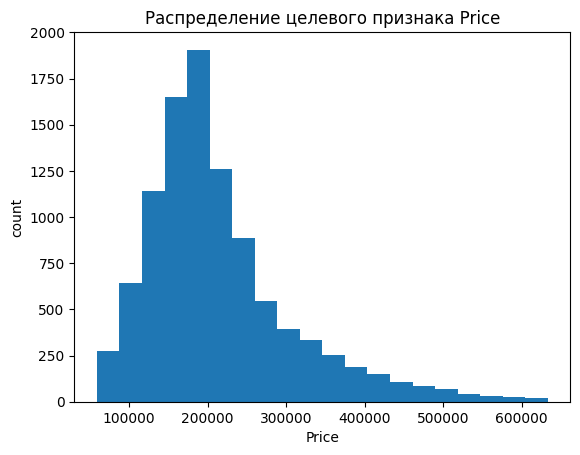

In [ ]:
plt.title('Распределение целевого признака Price')
df['Price'].plot(kind="hist", bins=20)
plt.ylabel('count')
plt.xlabel('Price')

Проверьте описательные статистики датасета, есть ли выбросы

In [ ]:
df.describe()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Price
count,10000.00000,10000.000000,10000.000000,10000.000000,7887.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,5202.000000,10000.000000,10000.000000,10000.000000
mean,8383.40770,50.400800,1.890500,56.315775,37.199645,6.273300,8.526700,12.609400,3.990166e+03,0.118858,24.687000,5352.157400,8.039200,1142.904460,1.319500,4.231300,214138.857399
std,4859.01902,43.587592,0.839512,21.058732,86.241209,28.560917,5.241148,6.775974,2.005003e+05,0.119025,17.532614,4006.799803,23.831875,1021.517264,1.493601,4.806341,92872.293865
min,0.00000,0.000000,0.000000,1.136859,0.370619,0.000000,1.000000,0.000000,1.910000e+03,0.000000,0.000000,168.000000,0.000000,0.000000,0.000000,0.000000,59174.778028
25%,4169.50000,20.000000,1.000000,41.774881,22.769832,1.000000,4.000000,9.000000,1.974000e+03,0.017647,6.000000,1564.000000,0.000000,350.000000,0.000000,1.000000,153872.633942
50%,8394.50000,36.000000,2.000000,52.513310,32.781260,6.000000,7.000000,13.000000,1.977000e+03,0.075424,25.000000,5285.000000,2.000000,900.000000,1.000000,3.000000,192269.644879
75%,12592.50000,75.000000,2.000000,65.900625,45.128803,9.000000,12.000000,17.000000,2.001000e+03,0.195781,36.000000,7227.000000,5.000000,1548.000000,2.000000,6.000000,249135.462171
max,16798.00000,209.000000,19.000000,641.065193,7480.592129,2014.000000,42.000000,117.000000,2.005201e+07,0.521867,74.000000,19083.000000,141.000000,4849.000000,6.000000,23.000000,633233.466570


Обработайте выбросы в одной из переменных
Обработайте пропуски в одной из переменных

In [ ]:
columns_to_fill = ['LifeSquare', 'Healthcare_1']
for col in columns_to_fill:
  median_val = df[col].median()
  df[col] = df[col].fillna(median_val)

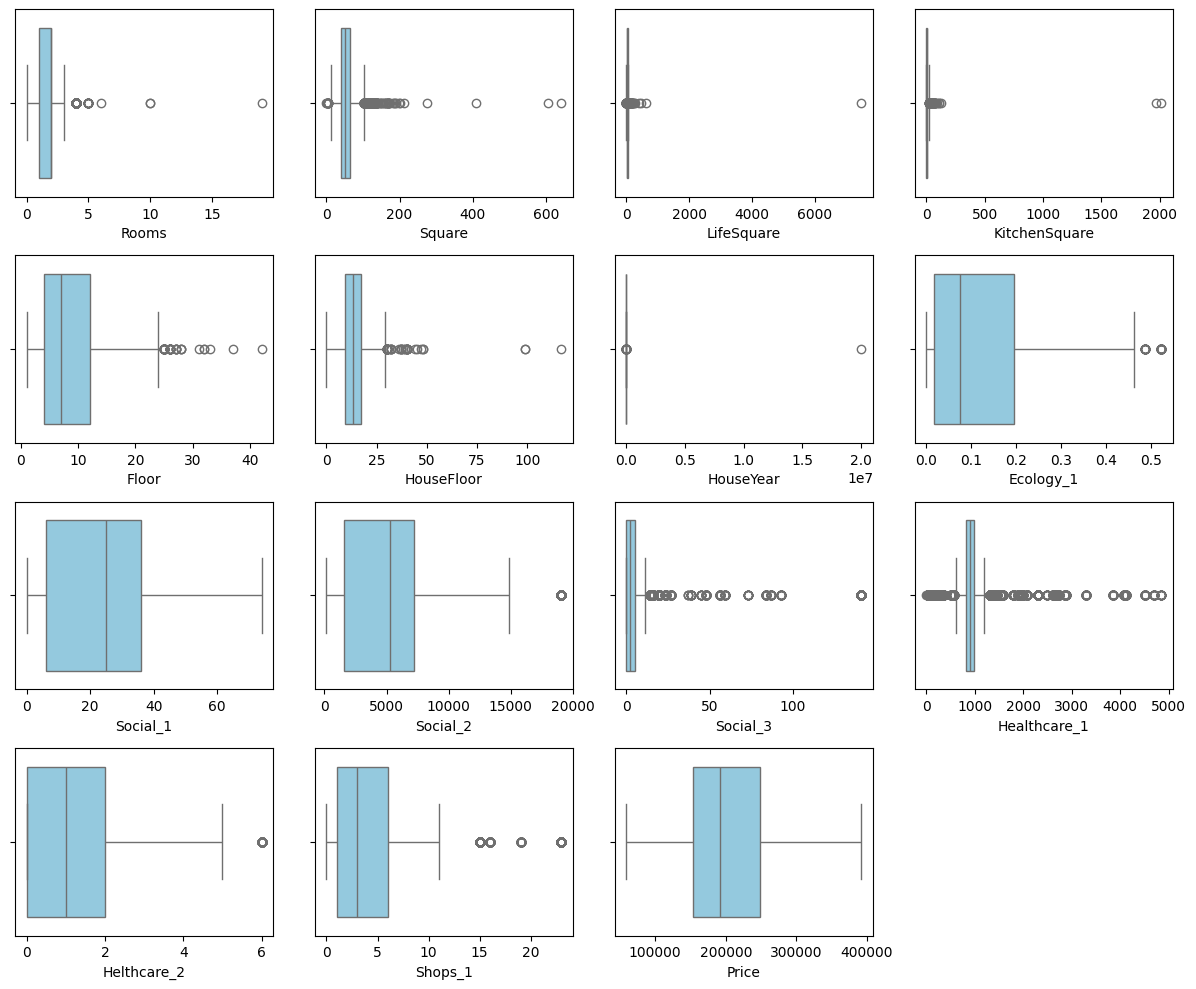

In [ ]:
df_num_features = df.select_dtypes(include=['float64', 'int64'])
df_num_features.drop(columns=['Id', 'DistrictId'], axis=1, inplace=True)

plt.figure(figsize=(12, 10))
for i, col in enumerate(df_num_features):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df[col], color='skyblue')

plt.tight_layout()
plt.show()

In [ ]:
for col in df_num_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower=lower, upper=upper)

Проверьте, что ни вывыбросов, ни пропусков нет

In [ ]:
print('\nКоличество пропусков по столбцам после заполнения:')
print(df.isna().sum())


Количество пропусков по столбцам после заполнения:
Id               0
DistrictId       0
Rooms            0
Square           0
LifeSquare       0
KitchenSquare    0
Floor            0
HouseFloor       0
HouseYear        0
Ecology_1        0
Ecology_2        0
Ecology_3        0
Social_1         0
Social_2         0
Social_3         0
Healthcare_1     0
Helthcare_2      0
Shops_1          0
Shops_2          0
Price            0
dtype: int64


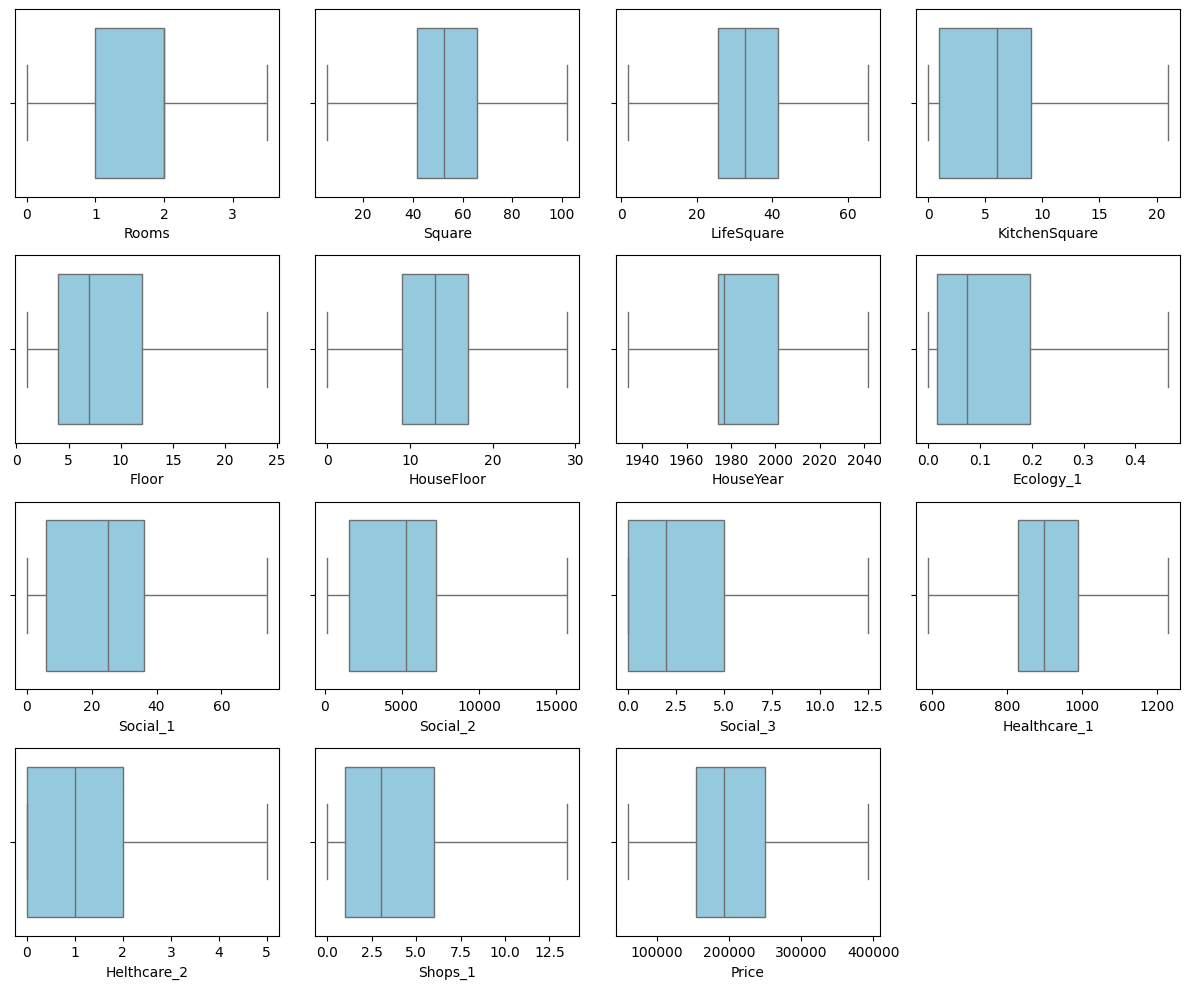

In [ ]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(df_num_features):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df[col], color='skyblue')

plt.tight_layout()
plt.show()

Подготовьте данные для модели, разбейте на train и test. Для валидации оставьте 20% данных

In [ ]:
X = df.drop(columns=['Price', 'Id'], axis=1)
y = df['Price']

In [ ]:
X = pd.get_dummies(X, dtype=int, drop_first=True)
X

,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Shops_1,Ecology_2_B,Ecology_3_B,Shops_2_B
0,27,3,102,32,10,4,10,2014,0,11,3097,0,900,0,0,1,1,1
1,22,1,39,23,8,7,8,1966,0,30,6207,1,1183,1,0,1,1,1
2,1,3,78,47,10,2,17,1988,0,33,5261,0,590,3,1,1,1,1
3,1,1,40,32,1,10,22,1977,0,1,264,0,900,0,1,1,1,1
4,94,2,64,38,9,16,16,1972,0,33,8667,2,900,0,6,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,61,2,49,33,6,3,12,1981,0,52,10311,6,900,1,9,1,1,1
9996,27,2,64,37,9,13,0,1977,0,2,629,1,900,0,0,1,1,0
9997,178,1,29,16,5,3,5,1958,0,20,4386,12,900,1,5,1,1,1
9998,21,1,32,22,5,3,9,1969,0,47,8004,3,590,3,5,1,1,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8000, 18) (2000, 18) (8000,) (2000,)
